# 02 — Feature Engineering: Technical Indicators

## Data Cutoff Decision

The Kaggle `sp500_headlines.csv` dataset ends on **2024-03-04**, meaning the final months
of 2024 would have zero news coverage. To ensure the test set has consistent headline
coverage, **all datasets are cut to end at 2023-12-31**.

### Updated temporal split

| Split | Date Range | Size |
|-------|-----------|------|
| Train | 2008-01-01 → 2020-12-31 | ~13 years |
| Val   | 2021-01-01 → 2022-06-30 | ~18 months |
| Test  | 2022-07-01 → 2023-12-31 | ~18 months |

`VAL_END` was moved from `2023-01-01` to `2022-07-01` to give ~18 months of test data
with good headline coverage (the headlines dataset covers through 2024-03-04, so the
entire test window is well-covered).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import (
    load_spy_data, load_vix_data,
    DATA_START, DATA_END, TRAIN_END, VAL_END,
    DATA_PROCESSED, get_temporal_split,
)
from src.features import compute_all_technical_features

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print(f'DATA_END={DATA_END}  TRAIN_END={TRAIN_END}  VAL_END={VAL_END}')

DATA_END=2023-12-31  TRAIN_END=2021-01-01  VAL_END=2022-07-01


## 1. Load and Filter Raw Data

In [2]:
spy = load_spy_data()
vix = load_vix_data()

# Filter to [DATA_START, DATA_END]
spy = spy.loc[DATA_START:DATA_END]
vix = vix.loc[DATA_START:DATA_END]

print(f'SPY: {spy.shape}  {spy.index[0].date()} → {spy.index[-1].date()}')
print(f'VIX: {vix.shape}  {vix.index[0].date()} → {vix.index[-1].date()}')
spy.head()

SPY: (4027, 5)  2008-01-02 → 2023-12-29
VIX: (4027, 5)  2008-01-02 → 2023-12-29


,Close,High,Low,Open,Volume
Date,,,,,
2008-01-02,103.495613,104.966684,102.745809,104.638190,204935600
2008-01-03,103.445610,103.895501,102.881470,103.481318,125133300
2008-01-04,100.910538,102.431590,100.624899,102.360175,232330900
2008-01-07,100.824837,101.567504,100.046462,101.267580,234991000
2008-01-08,99.196709,102.045992,98.861077,101.460429,326365700


## 2. Build Technical Feature Matrix

In [3]:
features = compute_all_technical_features(spy, vix)

print('Shape:', features.shape)
print(f'Date range: {features.index[0].date()} → {features.index[-1].date()}')
print()
print('Columns:')
for col in features.columns:
    print(' ', col)

Shape: (3828, 18)
Date range: 2008-10-15 → 2023-12-29

Columns:
  return_1d
  return_5d
  return_10d
  price_to_ma10
  price_to_ma20
  price_to_ma50
  price_to_ma100
  price_to_ma200
  volatility_5d
  volatility_10d
  volatility_20d
  volume_change
  volume_to_avg20
  vix_level
  vix_change_1d
  vix_change_5d
  vix_to_ma20
  target


## 3. NaN Check

In [4]:
nan_counts = features.isna().sum()
print('NaN counts per column:')
print(nan_counts[nan_counts > 0] if nan_counts.any() else 'No NaNs — clean!')
print()
print('Target distribution:')
print(features['target'].value_counts(normalize=True).rename({0: 'Down (0)', 1: 'Up (1)'}))

NaN counts per column:
No NaNs — clean!

Target distribution:
target
Up (1)      0.550418
Down (0)    0.449582
Name: proportion, dtype: float64


## 4. Correlation Heatmap

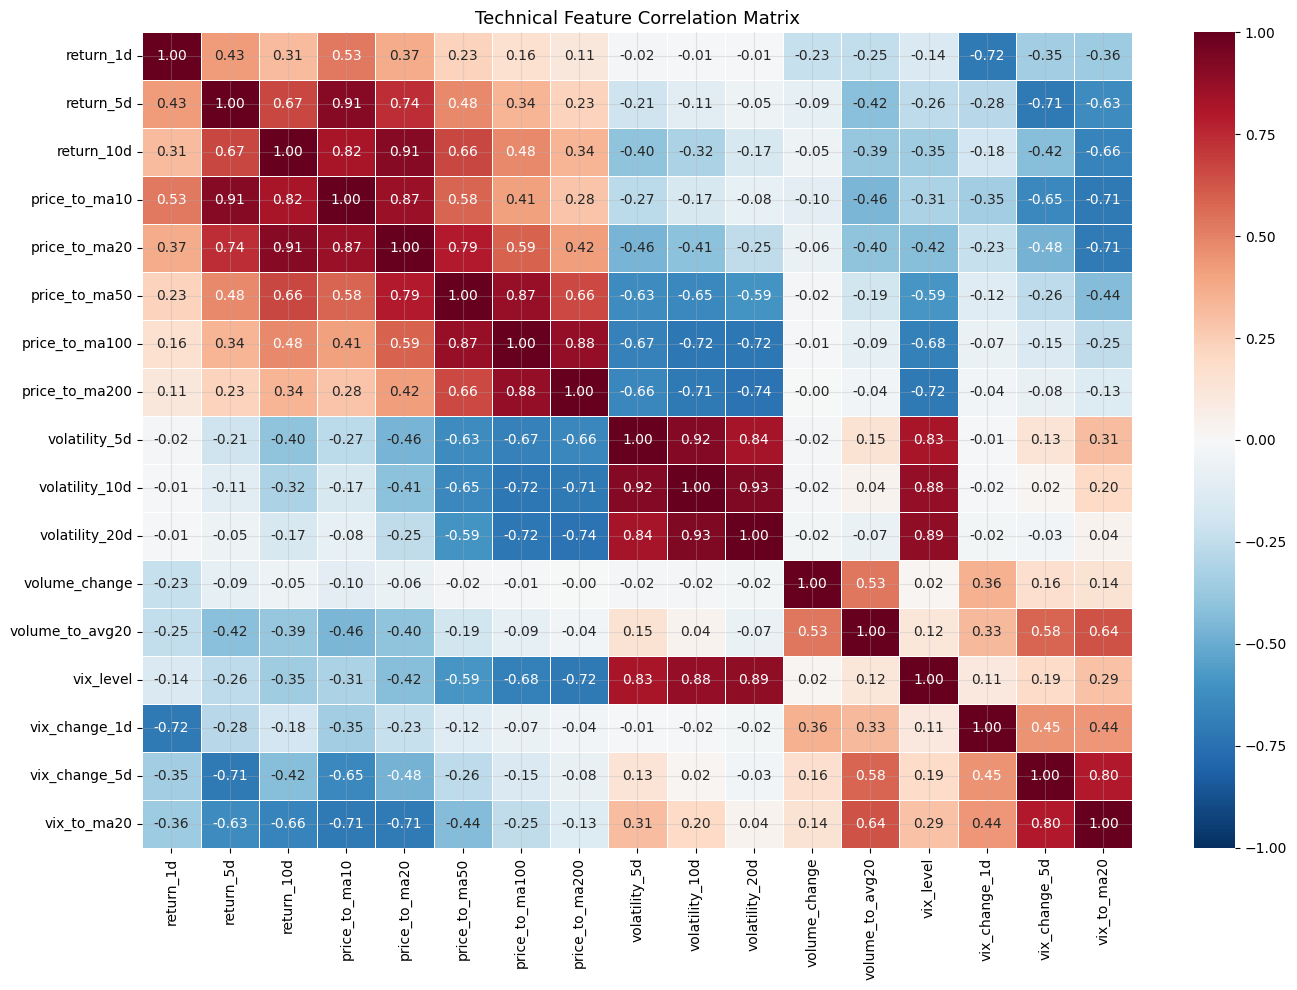

In [5]:
# Exclude target from heatmap
feat_cols = [c for c in features.columns if c != 'target']
corr = features[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Technical Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Save to data/processed/

In [6]:
out_path = DATA_PROCESSED / 'technical_features.csv'
features.to_csv(out_path)
print(f'Saved {features.shape[0]} rows × {features.shape[1]} cols → {out_path}')

Saved 3828 rows × 18 cols → /Users/shirleycheung/Desktop/FSA_AI_capstone_project/notebooks/../data/processed/technical_features.csv


## 6. Train / Val / Test Split Sizes

In [7]:
train, val, test = get_temporal_split(features)

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    start = split.index[0].date()
    end   = split.index[-1].date()
    pct   = len(split) / len(features) * 100
    print(f'{name:5s}: {len(split):4d} rows  ({start} → {end})  {pct:.1f}%')

Train: 3075 rows  (2008-10-15 → 2020-12-31)  80.3%
Val  :  376 rows  (2021-01-04 → 2022-06-30)  9.8%
Test :  377 rows  (2022-07-01 → 2023-12-29)  9.8%


---
## 7. Summary

| Output | Value |
|--------|-------|
| **Saved file** | `data/processed/technical_features.csv` |
| **Matrix shape** | 3,828 rows × 18 cols (17 features + target) |
| **Date range** | 2008-10-15 → 2023-12-29 (first 199 rows dropped due to MA-200 warmup) |
| **Missing values** | None — all indicators computed cleanly |
| **Target balance** | 55.0% Up / 45.0% Down |

**Technical features (17):** 1d/5d/10d returns, price-to-MA ratios (10/20/50/100/200), 5d/10d/20d volatility, volume change, volume-to-avg20, VIX level, VIX 1d/5d change, VIX-to-MA20.

**Train / Val / Test split:**
- Train: 3,075 rows (2008-10-15 → 2020-12-31) — 80%
- Val:     376 rows (2021-01-04 → 2022-06-30) — 10%
- Test:    377 rows (2022-07-01 → 2023-12-29) — 10%

The feature matrix is passed to notebook 04 (after embedding generation in notebook 03) for merging with news features.